# Phân tích Khám phá Tuyển sinh Đại học Việt Nam (EDA)
## Notebook 05: Phân tích theo Tổ hợp Xét tuyển

Notebook này thực hiện:
1. Thống kê tần suất xuất hiện và độ phổ biến của các tổ hợp xét tuyển (A00, A01, D01, B00...).
2. So sánh điểm chuẩn trung bình của các tổ hợp xét tuyển.
3. Phân tích sự chuyển dịch xu hướng sử dụng tổ hợp qua các năm.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_theme(style="whitegrid")

df = pd.read_csv("../data/processed/admission_processed.csv", encoding="utf-8-sig")

### 1. Độ phổ biến của các tổ hợp xét tuyển

In [2]:
group_counts = df['subject_group'].value_counts().reset_index()
group_counts.columns = ['subject_group', 'count']
group_counts['percentage'] = (group_counts['count'] / group_counts['count'].sum() * 100).round(2)
print(group_counts)

    subject_group  count  percentage
0             D01  24966       13.30
1             A00  22872       12.19
2             A01  20574       10.96
3             D07  11946        6.37
4             C01  10842        5.78
..            ...    ...         ...
128           C23      6        0.00
129           C24      6        0.00
130           C25      6        0.00
131           C26      6        0.00
132           D89      6        0.00

[133 rows x 3 columns]


/tmp/ipykernel_57910/1583728125.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='count', y='subject_group', data=group_counts.head(10), palette='muted')


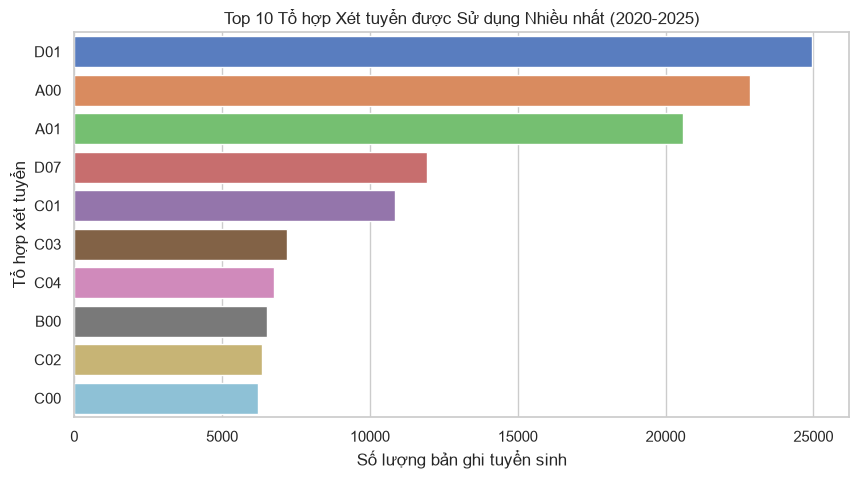

In [3]:
plt.figure(figsize=(10, 5))
sns.barplot(x='count', y='subject_group', data=group_counts.head(10), palette='muted')
plt.title('Top 10 Tổ hợp Xét tuyển được Sử dụng Nhiều nhất (2020-2025)')
plt.xlabel('Số lượng bản ghi tuyển sinh')
plt.ylabel('Tổ hợp xét tuyển')
plt.show()

### 2. So sánh điểm chuẩn của các tổ hợp phổ biến

In [4]:
# Lọc ra top 5 tổ hợp nhiều bản ghi nhất để so sánh phân phối điểm
top_5_groups = group_counts.head(5)['subject_group'].tolist()
df_top_groups = df[df['subject_group'].isin(top_5_groups)]
group_score_stats = df_top_groups.groupby('subject_group')['admission_score'].agg(['count', 'mean', 'median', 'std']).reset_index()
print(group_score_stats.round(2))

  subject_group  count   mean  median   std
0           A00  22872  20.12   20.05  4.15
1           A01  20574  20.19   20.29  4.22
2           C01  10842  19.61   19.65  4.13
3           D01  24966  19.70   19.28  4.26
4           D07  11946  20.64   20.63  3.96


/tmp/ipykernel_57910/429506619.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='subject_group', y='admission_score', data=df_top_groups, order=top_5_groups, palette='Set2')


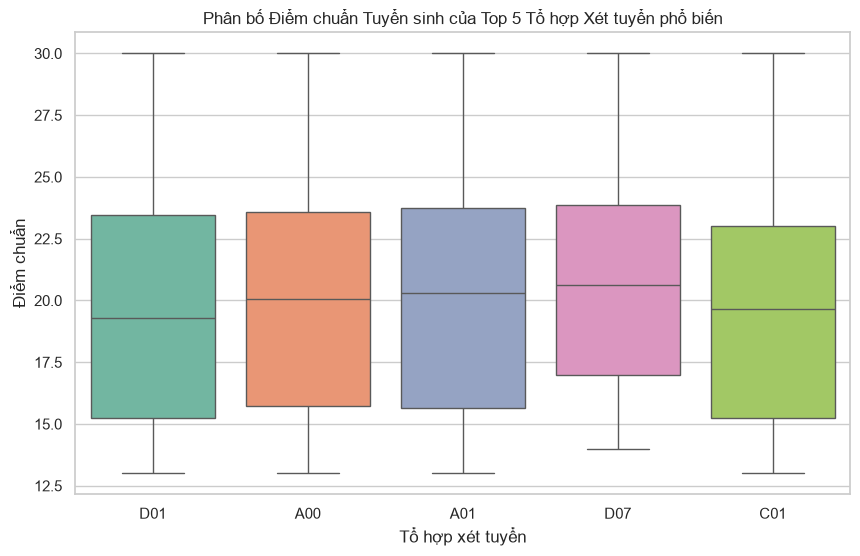

In [5]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='subject_group', y='admission_score', data=df_top_groups, order=top_5_groups, palette='Set2')
plt.title('Phân bố Điểm chuẩn Tuyển sinh của Top 5 Tổ hợp Xét tuyển phổ biến')
plt.xlabel('Tổ hợp xét tuyển')
plt.ylabel('Điểm chuẩn')
plt.show()